# 資料處理

## 檢查版本

In [94]:
import sys, xarray as xr
print("Python exe:", sys.executable)
print("Engines:", xr.backends.list_engines())

Python exe: /home/jundian/miniconda3/envs/geospatial-neural-adapter/bin/python
Engines: {'netcdf4': <NetCDF4BackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html, 'h5netcdf': <H5netcdfBackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using h5netcdf in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.H5netcdfBackendEntrypoint.html, 'scipy': <ScipyBackendEntrypoint>
  Open netCDF files (.nc, .nc4, .cdf and .gz) using scipy in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html, 'store': <StoreBackendEntrypoint>
  Open AbstractDataStore instances in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html}


## 讀nc4

In [95]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm


def check_data_folder(folder: str) -> bool:
    return os.path.exists(folder) and os.path.isdir(folder)


def load_data(file_path: str) -> xr.Dataset:
    """
    Load data from a NetCDF file, trying netcdf4 then h5netcdf.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    # 優先 netcdf4
    try:
        return xr.open_dataset(file_path, engine="netcdf4")
    except Exception as e1:
        # 改試 h5netcdf
        try:
            return xr.open_dataset(file_path, engine="h5netcdf")
        except Exception as e2:
            raise RuntimeError(
                f"Failed to open {file_path} with netcdf4 and h5netcdf.\n"
                f"e1: {e1}\n"
                f"e2: {e2}\n"
                "請確認這個環境有安裝 netCDF4 或 h5netcdf。"
            )


# ================= main program =================

data_folder = "nc4"
var_name = "T2M"  # 目標變數名稱（請確認檔內真的叫這個）

# 1. 檢查資料夾
if not check_data_folder(data_folder):
    raise FileNotFoundError(f"Data folder not found: {data_folder}")
print(f"Data folder found: {data_folder}")

# 2. 找出所有像 1980-01.nc4 的檔案
pattern = os.path.join(data_folder, "*.nc4")
file_list = sorted(glob.glob(pattern))

if len(file_list) == 0:
    raise FileNotFoundError(f"No nc4 files found with pattern: {pattern}")

print(f"Found {len(file_list)} files.")
print("First 5 files:", file_list[:5])

# 3. 用第一個檔案確認經緯度與變數存在，必要時自動偵測 var_name
with load_data(file_list[0]) as sample_data:
    print("Data variables in first file:")
    print(list(sample_data.data_vars))
    print("Coordinates:")
    print({k: sample_data[k].shape for k in sample_data.coords})

    # 找出所有長得像 (time, lat, lon) 的候選變數
    candidates = []
    for v in sample_data.data_vars:
        dims = set(sample_data[v].dims)
        if {"time", "lat", "lon"}.issubset(dims):
            candidates.append(v)

    # 如果原本設定的 var_name 不在，就試著自動改
    if var_name not in sample_data.data_vars:
        if len(candidates) == 1:
            auto_var = candidates[0]
            print(f"[Info] Variable '{var_name}' not found, auto-select '{auto_var}' as target.")
            var_name = auto_var
        else:
            raise KeyError(
                f"Variable '{var_name}' not found in file: {file_list[0]}\n"
                f"Available data_vars: {list(sample_data.data_vars)}\n"
                f"3D (time,lat,lon) candidates: {candidates}\n"
                "請將上方其中一個正確變數名稱填入 var_name。"
            )

    # 取經緯度
    if "lat" not in sample_data.coords or "lon" not in sample_data.coords:
        raise KeyError("lat/lon coordinates not found in sample file.")
    lat = sample_data["lat"].values
    lon = sample_data["lon"].values

nlat = lat.shape[0]
nlon = lon.shape[0]
print(f"Confirmed var_name = {var_name}")
print(f"Lat: {nlat}, Lon: {nlon}")


# 4. 逐檔讀入，累積到 list
data_list = []
time_list = []

for f in tqdm(file_list, desc="Combining"):
    with load_data(f) as ds:
        da = ds[var_name]  # (time, lat, lon)

        # 確保 lat/lon 一致（保險，可視情況註解）
        if da.sizes["lat"] != nlat or da.sizes["lon"] != nlon:
            raise ValueError(f"Lat/Lon size mismatch in file: {f}")

        # 資料轉 float32，省記憶體
        data_list.append(da.values.astype(np.float32))

        if "time" not in ds:
            raise KeyError(f"'time' coordinate not found in file: {f}")

        # decode_cf 確保時間是真正 datetime
        t = xr.decode_cf(ds)["time"].values
        time_list.append(t.astype("datetime64[ns]"))

# 5. 串起來 → (ntot, lat, lon) & DatetimeIndex
combined = np.concatenate(data_list, axis=0)   # (ntot, nlat, nlon)
time_array = np.concatenate(time_list, axis=0) # (ntot,)

if combined.shape[0] != time_array.shape[0]:
    raise ValueError(
        f"time length ({time_array.shape[0]}) "
        f"!= data length ({combined.shape[0]})"
    )

# 依時間排序（通常已排序，這裡是保險）
sort_idx = np.argsort(time_array)
combined = combined[sort_idx]
time_array = time_array[sort_idx]

time_index = pd.to_datetime(time_array)

print(f"Combined data shape: {combined.shape}")
print(f"Time index: {time_index[0]} -> {time_index[-1]} (len={len(time_index)})")

# 6. 攤平成 cell × time
ntot, nlat, nlon = combined.shape
ncell = nlat * nlon

# (cell, time)
y_all = combined.reshape(ntot, ncell).T

# 建立每個 cell 的 (lon, lat)
lon_grid, lat_grid = np.meshgrid(lon, lat)
gg = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])  # (cell, 2)

print(f"y_all shape: {y_all.shape}  (cells x time)")
print(f"gg shape: {gg.shape}        (cells x [lon, lat])")


Data folder found: nc4
Found 548 files.
First 5 files: ['nc4/1980-01.nc4', 'nc4/1980-02.nc4', 'nc4/1980-03.nc4', 'nc4/1980-04.nc4', 'nc4/1980-05.nc4']
Data variables in first file:
['T2M', 'T2MDEW', 'Var_T2M', 'T2MWET']
Coordinates:
{'lon': (576,), 'time': (1,), 'lat': (361,)}
Confirmed var_name = T2M
Lat: 361, Lon: 576


Combining: 100%|██████████| 548/548 [00:15<00:00, 35.31it/s]


Combined data shape: (548, 361, 576)
Time index: 1980-01-01 00:30:00 -> 2025-08-01 00:30:00 (len=548)
y_all shape: (207936, 548)  (cells x time)
gg shape: (207936, 2)        (cells x [lon, lat])


### 在地圖上輸出測站位置

Figure saved to: photo/grid_cells_world.png


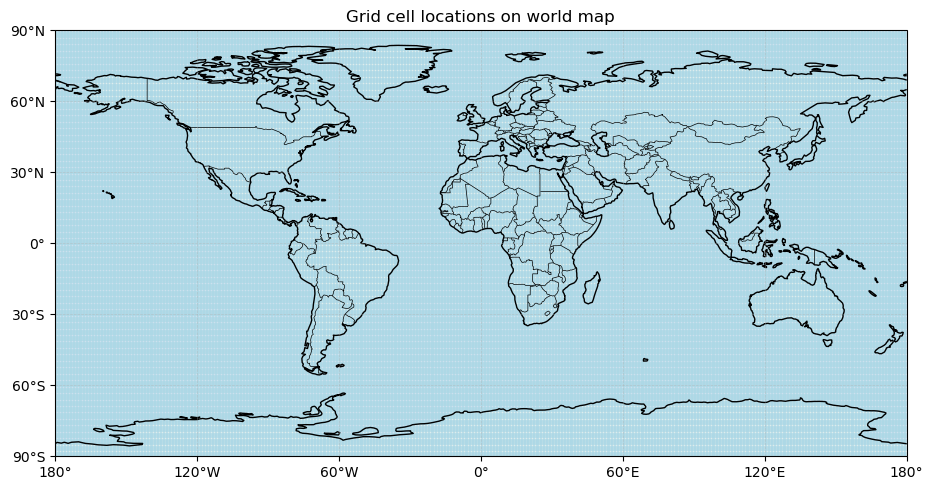

In [96]:
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np

# ===== 輸出資料夾與檔名 =====
output_dir = "photo"
os.makedirs(output_dir, exist_ok=True)
out_path = os.path.join(output_dir, "grid_cells_world.png")

# gg: (ncell, 2) = [lon, lat]
lons = gg[:, 0]
lats = gg[:, 1]

# 如果經度是 0~360，轉成 -180~180
if lons.max() > 180:
    lons = ((lons + 180) % 360) - 180

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# 海岸線、國界、陸地、海洋
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.OCEAN, alpha=0.3)

# 格點位置
ax.scatter(
    lons,
    lats,
    s=1,
    marker=".",
    color="lightblue",
    transform=ccrs.PlateCarree(),
)

ax.set_global()
ax.set_title("Grid cell locations on world map")

# ===== 經緯度刻度設定 =====
xticks = np.arange(-180, 181, 60)
yticks = np.arange(-90, 91, 30)

ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())

ax.xaxis.set_major_formatter(
    LongitudeFormatter(number_format=".0f", degree_symbol="°")
)
ax.yaxis.set_major_formatter(
    LatitudeFormatter(number_format=".0f", degree_symbol="°")
)

# 只畫格線，不要 gridliner 的文字（避免重複）
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.5,
    linestyle="--",
    alpha=0.5,
)

plt.tight_layout()

# 先存檔，再顯示
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {out_path}")

plt.show()


# 限制範圍抽樣 in USA

In [97]:
# ===== 只看美國本土範圍，並從中抽樣 25 個格點 =====
import numpy as np

# gg: (ncell, 2)；第 0 欄是 lon，第 1 欄是 lat
lon_all = gg[:, 0].astype(float)
lat_all = gg[:, 1].astype(float)

# 如果經度是 0~360，轉成 -180~180（如果本來就是 -180~180，這個轉換也不會壞掉）
lon_all_180 = ((lon_all + 180) % 360) - 180

# 美國本土 48 州的大致範圍（可以再微調）
lon_min, lon_max = -125, -66
lat_min, lat_max = 24, 50

# 建立遮罩：只保留在美國本土範圍內的格點
mask_us_mainland = (
    (lon_all_180 >= lon_min) & (lon_all_180 <= lon_max) &
    (lat_all      >= lat_min) & (lat_all      <= lat_max)
)

idx_us_mainland = np.where(mask_us_mainland)[0]
print(f"美國本土範圍內的格點數量: {len(idx_us_mainland)}")

if len(idx_us_mainland) == 0:
    raise ValueError("在設定的美國本土範圍內沒有格點，請調整 lon_min/max 或 lat_min/max。")

# 只保留美國本土子集合
y_us = y_all[idx_us_mainland, :]  # (n_us, ntot)
coords_us = np.column_stack([lon_all_180[idx_us_mainland], lat_all[idx_us_mainland]])  # (n_us, 2)

print(f"美國本土子集合 y_us shape: {y_us.shape}")
print(f"美國本土子集合 coords_us shape: {coords_us.shape}")

# 從美國本土格點中隨機抽樣 25 個（如果不足 25，就全部使用）
n_sample = min(25, len(idx_us_mainland))
np.random.seed(42)  # 為了可重現
sample_idx_in_us = np.random.choice(len(idx_us_mainland), size=n_sample, replace=False)

# 這是「在原始格點編號中的 index」
sample_idx_global = idx_us_mainland[sample_idx_in_us]

# 抽樣後的 time series 與座標
y_sample = y_all[sample_idx_global, :]  # (n_sample, ntot)
coords_sample = np.column_stack([lon_all_180[sample_idx_global], lat_all[sample_idx_global]])  # (n_sample, 2)

# 如果之後畫圖想分開拿 lon / lat：
lon_us_sample = coords_sample[:, 0]
lat_us_sample = coords_sample[:, 1]

print(f"抽樣 {n_sample} 個美國本土格點")
print("前 5 個 sample index (global):", sample_idx_global[:5])
print("前 5 個 sample 座標 (lon, lat):")
for i in range(min(5, n_sample)):
    print(f"  #{i}: lon={lon_us_sample[i]:.2f}, lat={lat_us_sample[i]:.2f}")


美國本土範圍內的格點數量: 5035
美國本土子集合 y_us shape: (5035, 548)
美國本土子集合 coords_us shape: (5035, 2)
抽樣 25 個美國本土格點
前 5 個 sample index (global): [153335 159677 145263 156825 138939]
前 5 個 sample 座標 (lon, lat):
  #0: lon=-105.62, lat=43.00
  #1: lon=-101.88, lat=48.50
  #2: lon=-110.62, lat=36.00
  #3: lon=-84.38, lat=46.00
  #4: lon=-103.12, lat=30.50


## 25個抽樣格點的圖

### 各站位置

Figure saved to: photo/sampled_mainland_us_cells_25.png


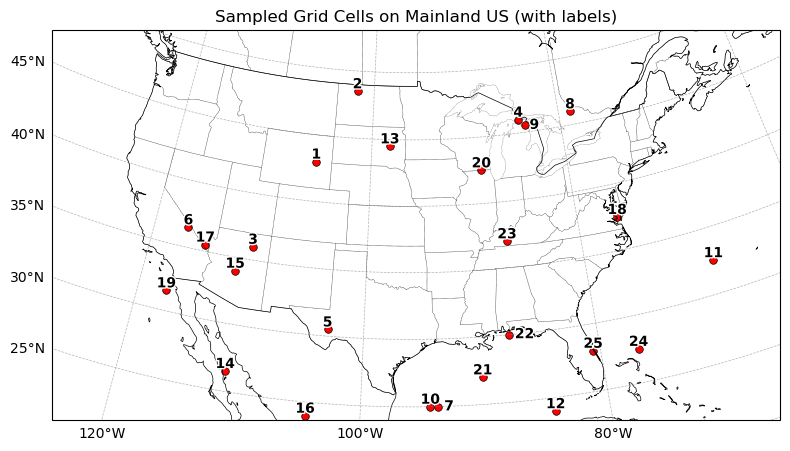

In [98]:
import os
import matplotlib.patheffects as pe  # 前面如果已經 import 就不用再寫

# 確保 photo 資料夾存在
out_dir = "photo"
os.makedirs(out_dir, exist_ok=True)

# ===== 畫圖（美國本土投影）=====
proj = ccrs.LambertConformal(central_longitude=-96, central_latitude=39)

fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=proj)

# 聚焦在美國本土
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# 地圖元素
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3, linestyle=":")

# ====== 25 個格點版本：確保 n_sample = 25 ======
n_sample = 25

# 如果你前面抽樣的結果 lon_us_sample / lat_us_sample 不是 25 個
# 可以在這裡保險起見截取前 25 個（建議你前面就抽 25 個比較乾淨）
lon_plot = lon_us_sample[:n_sample]
lat_plot = lat_us_sample[:n_sample]

# 畫出抽樣的 25 個格點（紅色）
ax.scatter(
    lon_plot,
    lat_plot,
    s=30,
    color="red",
    marker="o",
    edgecolor="black",
    linewidth=0.5,
    transform=ccrs.PlateCarree(),
    label=f"Random {n_sample} sampled cells (Mainland US)",
)

# === 在每個格點加上標號 (1~25) ===
for i, (x, y) in enumerate(zip(lon_plot, lat_plot), start=1):

    # 預設：標號在點的上方
    x_text = x
    y_text = y
    ha = "center"
    va = "bottom"

    # 對 7、9、22 號：標號改放在點的右邊（需要就留，不需要可刪）
    if i in (7, 9, 22):
        x_text = x + 0.5   # 往右偏一點（度數可調）
        y_text = y
        ha = "left"
        va = "center"

    txt = ax.text(
        x_text,
        y_text,
        str(i),
        transform=ccrs.PlateCarree(),
        fontsize=10,
        ha=ha,
        va=va,
        clip_on=True,
        color="black",
        fontweight="bold",
    )
    txt.set_path_effects([
        pe.Stroke(linewidth=2, foreground="white"),
        pe.Normal()
    ])

# 網格與標籤
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.6,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.x_inline = False
gl.y_inline = False
gl.rotate_labels = False
gl.xlabel_style = {"rotation": 0}
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

ax.set_title("Sampled Grid Cells on Mainland US (with labels)")

plt.tight_layout()

# 存到 photo 資料夾（檔名也改成 25）
out_path = os.path.join(out_dir, "sampled_mainland_us_cells_25.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {out_path}")

plt.show()

### 各站 seasonal_decompose

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from statsmodels.tsa.seasonal import seasonal_decompose

# ============================================================
# 0) 重置 matplotlib 全域樣式
# ============================================================
mpl.rcdefaults()
plt.style.use("default")   # 確保用預設色盤（C0=藍）

def force_fig_color(fig, color="C0"):
    """
    把 statsmodels result.plot() 產生的線/點顏色全部強制改成指定色（預設 C0=藍）
    """
    for ax in fig.axes:
        for line in ax.get_lines():
            line.set_color(color)
        for col in ax.collections:
            try:
                col.set_color(color)
            except Exception:
                pass

# ============================================================
# 1) 基本輸入
# ============================================================
ncell, T = y_all.shape
print(f"Input y_all: {ncell} cells, T={T} time steps")
print(f"# of sampled cells (original) = {len(sample_idx_global)}")

# ============================================================
# 2) 只做 25 個格點
# ============================================================
N_SAMPLE = 25
sample_idx_global_25 = np.asarray(sample_idx_global)[:N_SAMPLE]
coords_sample_25 = np.asarray(coords_sample)[:N_SAMPLE]
print(f"# of sampled cells (used) = {len(sample_idx_global_25)}")

# ============================================================
# 3) 輸出資料夾
# ============================================================
output_dir = "photo/seasonal_25cells"
os.makedirs(output_dir, exist_ok=True)
print(f"Saving seasonal decomposition outputs to: {output_dir}")

# ============================================================
# 4) 時序設定
# ============================================================
period = 12

# ============================================================
# 5) 分解 + 畫圖（cell_0 ~ cell_24）
# ============================================================
for k, cell_id in enumerate(sample_idx_global_25, start=0):
    series = pd.Series(y_all[cell_id, :], index=time_index)

    if series.isna().any():
        series = series.interpolate(limit_direction="both")

    result = seasonal_decompose(
        series,
        model="additive",
        period=period,
        extrapolate_trend="freq"
    )

    fig = result.plot()
    fig.set_size_inches(10, 6)

    # 強制藍色
    
    force_fig_color(fig, color="C0")

    # 標題改為 cell_0 ~ cell_24
    fig.suptitle(f"Seasonal-Trend Decomposition - cell_{k}", y=0.98)

    # 檔名也對齊
    save_name = f"cell_{k:02d}.png"
    save_path = os.path.join(output_dir, save_name)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    print(f"[cell_{k}] Saved: {save_name}")

print("Done! All 25 sampled cells seasonal decomposition saved (cell_0 ~ cell_24).")


Input y_all: 207936 cells, T=548 time steps
# of sampled cells (original) = 25
# of sampled cells (used) = 25
Saving seasonal decomposition outputs to: photo/seasonal_25cells
[cell_0] Saved: cell_00.png
[cell_1] Saved: cell_01.png
[cell_2] Saved: cell_02.png
[cell_3] Saved: cell_03.png
[cell_4] Saved: cell_04.png
[cell_5] Saved: cell_05.png
[cell_6] Saved: cell_06.png
[cell_7] Saved: cell_07.png
[cell_8] Saved: cell_08.png
[cell_9] Saved: cell_09.png
[cell_10] Saved: cell_10.png
[cell_11] Saved: cell_11.png
[cell_12] Saved: cell_12.png
[cell_13] Saved: cell_13.png
[cell_14] Saved: cell_14.png
[cell_15] Saved: cell_15.png
[cell_16] Saved: cell_16.png
[cell_17] Saved: cell_17.png
[cell_18] Saved: cell_18.png
[cell_19] Saved: cell_19.png
[cell_20] Saved: cell_20.png
[cell_21] Saved: cell_21.png
[cell_22] Saved: cell_22.png
[cell_23] Saved: cell_23.png
[cell_24] Saved: cell_24.png
Done! All 25 sampled cells seasonal decomposition saved (cell_0 ~ cell_24).


### Raw data & mean

y_all shape = (207936, 548), number of sampled cells (original) = 25
number of sampled cells (used) = 25
Figures will be saved to: photo


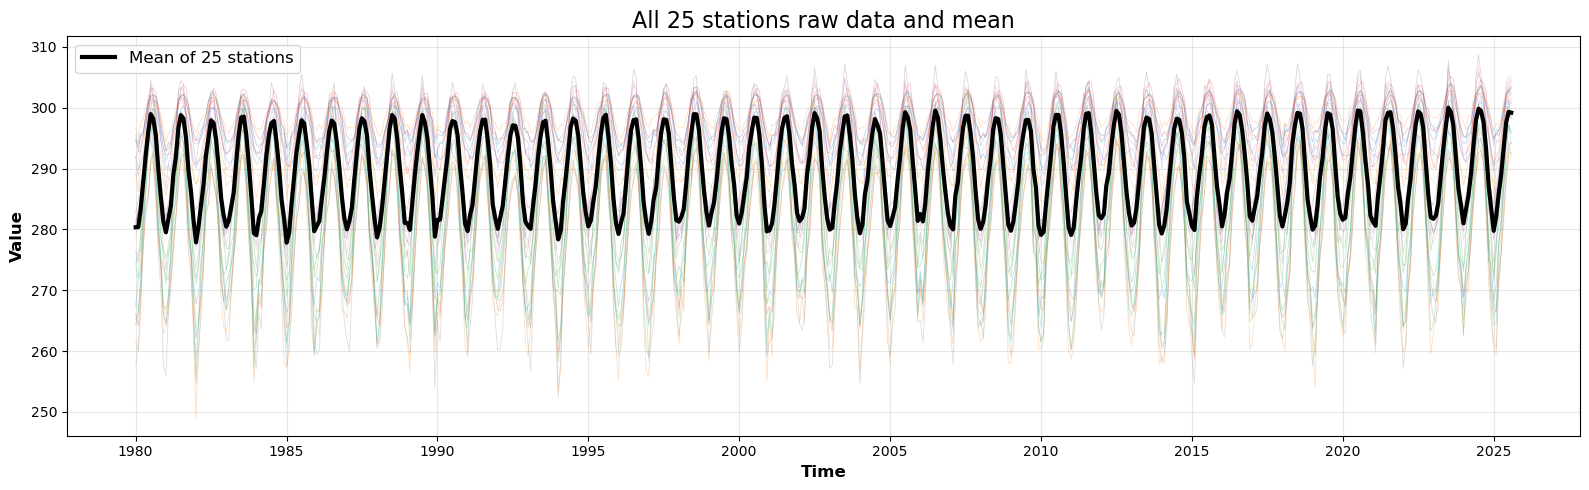

Figure saved to: photo/all_25_stations_raw_and_mean.png


In [100]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ===== 1. 準備資料：取出 25 個抽樣格點 =====
ncell, T = y_all.shape
print(f"y_all shape = {y_all.shape}, number of sampled cells (original) = {len(sample_idx_global)}")

N_SAMPLE = 25
sample_idx_25 = np.asarray(sample_idx_global)[:N_SAMPLE]

# 取出 25 個格點的資料 → (25, T)
vals_25 = y_all[sample_idx_25, :]          # (25, T)
idx = pd.DatetimeIndex(time_index)         # 確保是 DatetimeIndex

print(f"number of sampled cells (used) = {vals_25.shape[0]}")

# ===== 2. 建立輸出資料夾 =====
out_dir = "photo"
os.makedirs(out_dir, exist_ok=True)
print(f"Figures will be saved to: {out_dir}")

# ===== 3. 計算 25 個格點的共同平均（沿 cells 平均）=====
mean_25 = vals_25.mean(axis=0)        # shape: (T,)

# ===== 4. 繪圖（所有 raw + 一條 mean）=====
plt.figure(figsize=(16, 5))

# 25 條原始序列（淡）
for j in range(vals_25.shape[0]):
    plt.plot(
        idx,
        vals_25[j, :],
        linewidth=0.6,
        alpha=0.25
    )

# 共同平均（黑粗線）
plt.plot(
    idx,
    mean_25,
    color="black",
    linewidth=3,
    label="Mean of 25 stations"
)

plt.title("All 25 stations raw data and mean", fontsize=16)
plt.xlabel("Time", fontsize=12, fontweight="bold")
plt.ylabel("Value", fontsize=12, fontweight="bold")
plt.grid(alpha=0.3)
plt.legend(loc="upper left", fontsize=12)

plt.tight_layout()

out_path = os.path.join(out_dir, "all_25_stations_raw_and_mean.png")
plt.savefig(out_path, dpi=150)
plt.show()
plt.close()

print(f"Figure saved to: {out_path}")


### Raw data ACF/PACF

In [101]:
import os
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf

def plot_acf_pacf_like_example(
    x: np.ndarray,
    cell_name: str,
    out_path: str,
    nlags: int = 40,
    pacf_method: str = "ywm",
    fixed_ci: bool = True,
    skip_lag0: bool = False,   # 你想保留 lag0 就 False；想不畫就 True
):
    """
    上 ACF、下 PACF、藍色虛線固定 CI、黑 stem + 點
    y 軸改為自動縮放（不固定 [-1,1]）
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    N = len(x)
    if N < 5:
        raise ValueError(f"{cell_name}: series too short after cleaning (N={N})")

    nlags_use = min(nlags, N - 2)

    acf_vals = acf(x, nlags=nlags_use, fft=True)
    pacf_vals = pacf(x, nlags=nlags_use, method=pacf_method)

    lags = np.arange(nlags_use + 1)

    # 固定 CI：±1.96/sqrt(N)
    ci = 1.96 / np.sqrt(N) if fixed_ci else 1.96 / np.sqrt(N)

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    def _stem_with_dots(ax, y, title):
        ax.axhline(0, color="black", linewidth=2)

        # 決定要不要畫 lag0
        if skip_lag0:
            use_lags = lags[1:]
            use_y = y[1:]
        else:
            use_lags = lags
            use_y = y

        ax.vlines(use_lags, 0, use_y, color="black", linewidth=2)
        ax.scatter(use_lags, use_y, color="black", s=50, zorder=3)

        ax.axhline(ci, color="blue", linestyle="--", linewidth=2)
        ax.axhline(-ci, color="blue", linestyle="--", linewidth=2)

        ax.set_title(title, fontsize=18)
        ax.grid(True, alpha=0.35)

        # ===== 關鍵：y 軸自動縮放（含 CI）=====
        max_abs = float(np.nanmax(np.abs(use_y))) if len(use_y) > 0 else 0.0
        max_abs = max(max_abs, ci * 1.5, 0.1)  # 至少留一點高度
        pad = 0.10 * max_abs
        ax.set_ylim(-(max_abs + pad), (max_abs + pad))

    _stem_with_dots(axes[0], acf_vals,  f"Raw Data ACF - {cell_name}")
    _stem_with_dots(axes[1], pacf_vals, f"Raw Data PACF - {cell_name}")

    axes[1].set_xlabel("Lag", fontsize=16, fontweight="bold")

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# 25 個格點：Raw data
# ============================================================
N_SAMPLE = 25
sample_idx_25 = np.asarray(sample_idx_global)[:N_SAMPLE]
data_2d = y_all[sample_idx_25, :]  # (25, T)

out_dir = "photo/raw_acf_pacf_25cells"
os.makedirs(out_dir, exist_ok=True)

for k in range(N_SAMPLE):
    cell_name = f"cell_{k}"
    x = data_2d[k, :]

    out_path = os.path.join(out_dir, f"{cell_name}_raw_acf_pacf.png")
    plot_acf_pacf_like_example(
        x=x,
        cell_name=cell_name,
        out_path=out_path,
        nlags=40,
        pacf_method="ywm",
        fixed_ci=True,
        skip_lag0=False,   # 你想保留 lag0 就 False
    )
    print(f"[{k+1}/{N_SAMPLE}] Saved: {out_path}")

print("Done! Saved ACF/PACF figures (auto y-limits).")


[1/25] Saved: photo/raw_acf_pacf_25cells/cell_0_raw_acf_pacf.png
[2/25] Saved: photo/raw_acf_pacf_25cells/cell_1_raw_acf_pacf.png
[3/25] Saved: photo/raw_acf_pacf_25cells/cell_2_raw_acf_pacf.png
[4/25] Saved: photo/raw_acf_pacf_25cells/cell_3_raw_acf_pacf.png
[5/25] Saved: photo/raw_acf_pacf_25cells/cell_4_raw_acf_pacf.png
[6/25] Saved: photo/raw_acf_pacf_25cells/cell_5_raw_acf_pacf.png
[7/25] Saved: photo/raw_acf_pacf_25cells/cell_6_raw_acf_pacf.png
[8/25] Saved: photo/raw_acf_pacf_25cells/cell_7_raw_acf_pacf.png
[9/25] Saved: photo/raw_acf_pacf_25cells/cell_8_raw_acf_pacf.png
[10/25] Saved: photo/raw_acf_pacf_25cells/cell_9_raw_acf_pacf.png
[11/25] Saved: photo/raw_acf_pacf_25cells/cell_10_raw_acf_pacf.png
[12/25] Saved: photo/raw_acf_pacf_25cells/cell_11_raw_acf_pacf.png
[13/25] Saved: photo/raw_acf_pacf_25cells/cell_12_raw_acf_pacf.png
[14/25] Saved: photo/raw_acf_pacf_25cells/cell_13_raw_acf_pacf.png
[15/25] Saved: photo/raw_acf_pacf_25cells/cell_14_raw_acf_pacf.png
[16/25] Saved:

## DLinaer

In [102]:
# # ===== DLinear LOCAL grid search around best-known setting (focus on lowering TEST MSE) =====
# import time
# import numpy as np
# import pandas as pd
# from itertools import product

# from darts import TimeSeries
# from darts.models import DLinearModel
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# print("\n===== DLinear LOCAL GRID SEARCH (focus on TEST MSE) =====")

# # ============================================================
# # 0) 以你目前「已知 TEST MSE 最小」組合為中心做局部搜尋
# #    你圖上最佳：input=48, output=24, kernel=25, epochs=50, cov=False, revin=True
# # ============================================================
# INPUT_CHUNK_LENGTH_SET  = {36, 48, 60}           # 圍繞 48 做小範圍搜尋
# OUTPUT_CHUNK_LENGTH_SET = {24}                  # 固定 24（你目前最佳就在 24）
# KERNEL_SIZE_SET         = {19, 25, 31}  # 圍繞 25 做小範圍搜尋
# N_EPOCHS_SET            = {30, 50, 80}          # 小幅調整

# USE_COVARIATES_SET      = {False}               # 先專注 cov=False
# REVIN_SET               = {True}                # 先專注 revin=True

# RANDOM_STATE = 42

# # ============================================================
# # 0.1) 另外可調：optimizer / regularization
# # ============================================================
# BATCH_SIZE_SET          = {16, 32, 64}
# LR_SET                  = {3e-4, 1e-3}
# WEIGHT_DECAY_SET        = {0.0, 1e-6, 1e-5, 1e-4}
# CONST_INIT_SET          = {True, False}

# # ============================================================
# # 0.2) 輸出控制（避免爆版）
# # ============================================================
# VERBOSE = 0          # 0=只印「目前第幾個」；1=每組印完整設定；2=每20組印一次
# TOPK = 8
# SAVE_CSV = True
# OUT_CSV = "dlinear_local_grid_results.csv"

# # 訓練輸出壓到最低
# PL_TRAINER_KWARGS = {
#     "enable_progress_bar": False,
#     "logger": False,
#     "enable_checkpointing": False,
# }

# # ============================================================
# # 1) 建 target DataFrame：25 個格點 × T 時間點（原始單位）
# # ============================================================
# SAMPLE_SIZE = n_sample  # 預期是 25
# T = y_sample.shape[1]

# ts_df = pd.DataFrame(
#     y_sample.T,
#     index=time_index,
#     columns=[f"cell_{i}" for i in range(SAMPLE_SIZE)]
# ).astype("float32")

# print("Total time steps:", T)
# print("ts_df shape:", ts_df.shape)

# # ============================================================
# # 2) month covariate（保留，但本次預設不使用）
# # ============================================================
# month_values = time_index.month.astype("float32")
# month_df = pd.DataFrame({"month": month_values}, index=time_index)
# month_ts = TimeSeries.from_dataframe(month_df.astype("float32"))

# # ============================================================
# # 3) 切成 70 / 15 / 15（train / val / test）
# # ============================================================
# train_frac = 0.7
# val_frac   = 0.15

# cut_train = int(T * train_frac)
# cut_val   = int(T * (train_frac + val_frac))

# idx = ts_df.index
# split_1_time = idx[cut_train]
# split_2_time = idx[cut_val]

# ts_all_raw = TimeSeries.from_dataframe(ts_df)
# train_raw, tmp_raw = ts_all_raw.split_before(split_1_time)
# val_raw, test_raw  = tmp_raw.split_before(split_2_time)

# print(f"Train len (raw): {len(train_raw)}, Val len: {len(val_raw)}, Test len: {len(test_raw)}")

# month_train, tmp_month = month_ts.split_before(split_1_time)
# month_val, month_test  = tmp_month.split_before(split_2_time)

# assert len(month_train) == len(train_raw)
# assert len(month_val) == len(val_raw)
# assert len(month_test) == len(test_raw)

# # ============================================================
# # 4) 用 train 統計量標準化
# # ============================================================
# train_df = ts_df.iloc[:cut_train]
# mean_vec = train_df.mean(axis=0)
# std_vec  = train_df.std(axis=0).replace(0.0, 1.0)

# ts_df_scaled  = (ts_df - mean_vec) / std_vec
# ts_all_scaled = TimeSeries.from_dataframe(ts_df_scaled)

# train_ts, tmp_ts = ts_all_scaled.split_before(split_1_time)
# val_ts, test_ts  = tmp_ts.split_before(split_2_time)

# T_train, T_val, T_test = len(train_ts), len(val_ts), len(test_ts)

# vals_all      = ts_df.to_numpy(dtype=np.float32)
# val_true_raw  = vals_all[cut_train:cut_val, :]
# test_true_raw = vals_all[cut_val:, :]

# def inverse_scale(x: np.ndarray) -> np.ndarray:
#     return x * std_vec.values + mean_vec.values

# print("\n[Scaled TimeSeries lengths]")
# print("T_train =", T_train, "T_val =", T_val, "T_test =", T_test)

# train_val_ts    = train_ts.concatenate(val_ts)
# month_train_val = month_train.concatenate(month_val)

# # ============================================================
# # 5) Local grid search
# # ============================================================
# def _ts_to_2d(ts: TimeSeries) -> np.ndarray:
#     arr = np.asarray(ts.all_values(copy=False))
#     if arr.ndim == 3:
#         arr = arr[..., 0]
#     return arr

# def eval_one_setting(in_len, out_len, ksz, nep, use_cov, use_revin, bs, lr, wd, const_init):
#     common_kwargs = dict(
#         input_chunk_length=in_len,
#         output_chunk_length=out_len,
#         kernel_size=ksz,
#         n_epochs=nep,
#         random_state=RANDOM_STATE,
#         use_reversible_instance_norm=use_revin,
#         batch_size=bs,
#         optimizer_kwargs={"lr": lr, "weight_decay": wd},
#         const_init=const_init,
#         pl_trainer_kwargs=PL_TRAINER_KWARGS,
#         log_tensorboard=False,
#         save_checkpoints=False,
#     )

#     # --- VAL ---
#     model_val = DLinearModel(**common_kwargs)

#     fit_kwargs_val = {"series": train_ts, "verbose": False}
#     if use_cov:
#         fit_kwargs_val["past_covariates"] = month_train
#         fit_kwargs_val["future_covariates"] = month_train
#     model_val.fit(**fit_kwargs_val)

#     pred_kwargs_val = {"n": T_val, "verbose": False, "show_warnings": False}
#     if use_cov:
#         pred_kwargs_val["past_covariates"] = month_ts
#         pred_kwargs_val["future_covariates"] = month_ts
#     pred_val = model_val.predict(**pred_kwargs_val)

#     pred_val_raw = inverse_scale(_ts_to_2d(pred_val))

#     # --- TEST ---
#     model_test = DLinearModel(**common_kwargs)

#     fit_kwargs_test = {"series": train_val_ts, "verbose": False}
#     if use_cov:
#         fit_kwargs_test["past_covariates"] = month_train_val
#         fit_kwargs_test["future_covariates"] = month_train_val
#     model_test.fit(**fit_kwargs_test)

#     pred_kwargs_test = {"n": T_test, "verbose": False, "show_warnings": False}
#     if use_cov:
#         pred_kwargs_test["past_covariates"] = month_ts
#         pred_kwargs_test["future_covariates"] = month_ts
#     pred_test = model_test.predict(**pred_kwargs_test)

#     pred_test_raw = inverse_scale(_ts_to_2d(pred_test))

#     # --- metrics ---
#     y_val_true  = val_true_raw.reshape(-1, SAMPLE_SIZE)
#     y_val_pred  = pred_val_raw.reshape(-1, SAMPLE_SIZE)
#     y_test_true = test_true_raw.reshape(-1, SAMPLE_SIZE)
#     y_test_pred = pred_test_raw.reshape(-1, SAMPLE_SIZE)

#     mse_val  = float(mean_squared_error(y_val_true,  y_val_pred))
#     mae_val  = float(mean_absolute_error(y_val_true, y_val_pred))
#     rmse_val = float(np.sqrt(mse_val))
#     r2_val   = float(r2_score(y_val_true, y_val_pred))

#     mse_test  = float(mean_squared_error(y_test_true,  y_test_pred))
#     mae_test  = float(mean_absolute_error(y_test_true, y_test_pred))
#     rmse_test = float(np.sqrt(mse_test))
#     r2_test   = float(r2_score(y_test_true, y_test_pred))

#     return (rmse_val, mse_val, mae_val, r2_val), (rmse_test, mse_test, mae_test, r2_test)

# # 建 grid + 防呆：input_len >= output_len
# grid = list(product(
#     sorted(INPUT_CHUNK_LENGTH_SET),
#     sorted(OUTPUT_CHUNK_LENGTH_SET),
#     sorted(KERNEL_SIZE_SET),
#     sorted(N_EPOCHS_SET),
#     sorted(USE_COVARIATES_SET),
#     sorted(REVIN_SET),
#     sorted(BATCH_SIZE_SET),
#     sorted(LR_SET),
#     sorted(WEIGHT_DECAY_SET),
#     sorted(CONST_INIT_SET),
# ))
# grid = [g for g in grid if g[0] >= g[1]]

# results = []
# total = len(grid)
# print(f"\nTotal settings to run: {total}")

# for i, (in_len, out_len, ksz, nep, use_cov, use_revin, bs, lr, wd, cinit) in enumerate(grid, 1):
#     t0 = time.time()

#     if VERBOSE == 1:
#         print(f"\n[{i}/{total}] in={in_len}, out={out_len}, k={ksz}, ep={nep}, cov={use_cov}, revin={use_revin}, bs={bs}, lr={lr}, wd={wd}, const={cinit}")
#     elif VERBOSE == 2 and (i % 20 == 0 or i == 1 or i == total):
#         print(f"\n[{i}/{total}] ... running")
#     else:
#         # VERBOSE=0：每組都印「目前進度」，但只印很短，避免爆版
#         print(f"[{i}/{total}] running...")

#     (rmse_v, mse_v, mae_v, r2_v), (rmse_t, mse_t, mae_t, r2_t) = eval_one_setting(
#         in_len=in_len,
#         out_len=out_len,
#         ksz=ksz,
#         nep=nep,
#         use_cov=use_cov,
#         use_revin=use_revin,
#         bs=bs,
#         lr=lr,
#         wd=wd,
#         const_init=cinit,
#     )

#     dt = time.time() - t0
#     print(f"[{i}/{total}] done in {dt:.1f}s | TEST MSE={mse_t:.6f}, RMSE={rmse_t:.6f}")

#     row_common = dict(
#         input_chunk_length=in_len,
#         output_chunk_length=out_len,
#         kernel_size=ksz,
#         n_epochs=nep,
#         use_covariates=use_cov,
#         use_revin=use_revin,
#         batch_size=bs,
#         lr=lr,
#         weight_decay=wd,
#         const_init=cinit,
#     )

#     results.append({**row_common, "Split": "VAL",  "RMSE": rmse_v, "MSE": mse_v, "MAE": mae_v, "R2": r2_v})
#     results.append({**row_common, "Split": "TEST", "RMSE": rmse_t, "MSE": mse_t, "MAE": mae_t, "R2": r2_t})

# results_df = pd.DataFrame(results)

# # ============================================================
# # 6) 輸出（依 MSE 排序）
# # ============================================================
# if SAVE_CSV:
#     results_df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
#     print(f"\nSaved full results to: {OUT_CSV}")

# cols = [
#     "input_chunk_length", "output_chunk_length", "kernel_size",
#     "n_epochs", "batch_size", "lr", "weight_decay", "const_init",
#     "use_covariates", "use_revin", "Split",
#     "MSE", "RMSE", "MAE", "R2"
# ]

# test_top = results_df[results_df["Split"] == "TEST"].sort_values("MSE").head(TOPK)
# val_top  = results_df[results_df["Split"] == "VAL"].sort_values("MSE").head(TOPK)

# print(f"\n===== TOP {TOPK} (TEST, sorted by MSE) =====")
# print(test_top[cols].to_string(index=False))

# print(f"\n===== TOP {TOPK} (VAL, sorted by MSE) =====")
# print(val_top[cols].to_string(index=False))


In [103]:
# ===== Final DLinear with your BEST setting (25 sampled US grid cells) =====
import numpy as np
import pandas as pd

from darts import TimeSeries
from darts.models import DLinearModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n===== FINAL DLinear (BEST setting) on 25 sampled US cells =====")

# ============================================================
# 0) BEST setting (你提供的最佳組合)
# ============================================================
INPUT_CHUNK_LENGTH  = 36
OUTPUT_CHUNK_LENGTH = 24
KERNEL_SIZE         = 25
N_EPOCHS            = 50

USE_COVARIATES       = False
USE_REVIN            = True

BATCH_SIZE           = 64
LR                   = 0.0003
WEIGHT_DECAY         = 0.0
CONST_INIT           = True

RANDOM_STATE         = 42

# Trainer 輸出壓到最低，避免爆版
PL_TRAINER_KWARGS = {
    "enable_progress_bar": False,
    "logger": False,
    "enable_checkpointing": False,
}

# ============================================================
# 1) 建 target DataFrame：25 個格點 × T 時間點（原始單位）
# ============================================================
SAMPLE_SIZE = n_sample  # 預期是 25
T = y_sample.shape[1]

ts_df = pd.DataFrame(
    y_sample.T,   # (T, SAMPLE_SIZE)
    index=time_index,
    columns=[f"cell_{i}" for i in range(SAMPLE_SIZE)]
).astype("float32")

print("Total time steps:", T)
print("ts_df shape:", ts_df.shape)

# ============================================================
# 2) month covariate（保留；但 USE_COVARIATES=False 時不會用到）
# ============================================================
month_values = time_index.month.astype("float32")
month_df = pd.DataFrame({"month": month_values}, index=time_index)
month_ts = TimeSeries.from_dataframe(month_df.astype("float32"))

# ============================================================
# 3) 切成 70 / 15 / 15（train / val / test）
# ============================================================
train_frac = 0.7
val_frac   = 0.15

cut_train = int(T * train_frac)
cut_val   = int(T * (train_frac + val_frac))

idx = ts_df.index
split_1_time = idx[cut_train]
split_2_time = idx[cut_val]

ts_all_raw = TimeSeries.from_dataframe(ts_df)
train_raw, tmp_raw = ts_all_raw.split_before(split_1_time)
val_raw, test_raw  = tmp_raw.split_before(split_2_time)

print(f"Train len (raw): {len(train_raw)}, Val len: {len(val_raw)}, Test len: {len(test_raw)}")

month_train, tmp_month = month_ts.split_before(split_1_time)
month_val, month_test  = tmp_month.split_before(split_2_time)

assert len(month_train) == len(train_raw)
assert len(month_val) == len(val_raw)
assert len(month_test) == len(test_raw)

# ============================================================
# 4) 用 train 統計量標準化
# ============================================================
train_df = ts_df.iloc[:cut_train]
mean_vec = train_df.mean(axis=0)
std_vec  = train_df.std(axis=0).replace(0.0, 1.0)

ts_df_scaled  = (ts_df - mean_vec) / std_vec
ts_all_scaled = TimeSeries.from_dataframe(ts_df_scaled)

train_ts, tmp_ts = ts_all_scaled.split_before(split_1_time)
val_ts, test_ts  = tmp_ts.split_before(split_2_time)

T_train, T_val, T_test = len(train_ts), len(val_ts), len(test_ts)
print("\n[Scaled lengths] T_train =", T_train, "T_val =", T_val, "T_test =", T_test)

vals_all      = ts_df.to_numpy(dtype=np.float32)
val_true_raw  = vals_all[cut_train:cut_val, :]
test_true_raw = vals_all[cut_val:, :]

def inverse_scale(x: np.ndarray) -> np.ndarray:
    return x * std_vec.values + mean_vec.values

def _ts_to_2d(ts: TimeSeries) -> np.ndarray:
    arr = np.asarray(ts.all_values(copy=False))
    if arr.ndim == 3:
        arr = arr[..., 0]  # (T, C)
    return arr

# 用於 TEST 訓練：train+val
train_val_ts    = train_ts.concatenate(val_ts)
month_train_val = month_train.concatenate(month_val)

# ============================================================
# 5) 建立模型（VAL）
# ============================================================
model_kwargs = dict(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    kernel_size=KERNEL_SIZE,
    n_epochs=N_EPOCHS,
    random_state=RANDOM_STATE,
    use_reversible_instance_norm=USE_REVIN,
    batch_size=BATCH_SIZE,
    optimizer_kwargs={"lr": LR, "weight_decay": WEIGHT_DECAY},
    const_init=CONST_INIT,
    pl_trainer_kwargs=PL_TRAINER_KWARGS,
    log_tensorboard=False,
    save_checkpoints=False,
)

model_val = DLinearModel(**model_kwargs)

fit_kwargs_val = {"series": train_ts, "verbose": False}
pred_kwargs_val = {"n": T_val, "verbose": False, "show_warnings": False}

if USE_COVARIATES:
    fit_kwargs_val["past_covariates"] = month_train
    fit_kwargs_val["future_covariates"] = month_train
    pred_kwargs_val["past_covariates"] = month_ts
    pred_kwargs_val["future_covariates"] = month_ts

model_val.fit(**fit_kwargs_val)
pred_val = model_val.predict(**pred_kwargs_val)

pred_val_scaled = _ts_to_2d(pred_val)
pred_val_raw = inverse_scale(pred_val_scaled)

# ============================================================
# 6) 建立模型（TEST）：train+val → predict test
# ============================================================
model_test = DLinearModel(**model_kwargs)

fit_kwargs_test = {"series": train_val_ts, "verbose": False}
pred_kwargs_test = {"n": T_test, "verbose": False, "show_warnings": False}

if USE_COVARIATES:
    fit_kwargs_test["past_covariates"] = month_train_val
    fit_kwargs_test["future_covariates"] = month_train_val
    pred_kwargs_test["past_covariates"] = month_ts
    pred_kwargs_test["future_covariates"] = month_ts

model_test.fit(**fit_kwargs_test)
pred_test = model_test.predict(**pred_kwargs_test)

pred_test_scaled = _ts_to_2d(pred_test)
pred_test_raw = inverse_scale(pred_test_scaled)

# ============================================================
# 7) 計算指標（VAL / TEST）
# ============================================================
y_val_true  = val_true_raw.reshape(-1, SAMPLE_SIZE)
y_val_pred  = pred_val_raw.reshape(-1, SAMPLE_SIZE)
y_test_true = test_true_raw.reshape(-1, SAMPLE_SIZE)
y_test_pred = pred_test_raw.reshape(-1, SAMPLE_SIZE)

mse_val  = mean_squared_error(y_val_true,  y_val_pred)
mae_val  = mean_absolute_error(y_val_true, y_val_pred)
rmse_val = float(np.sqrt(mse_val))
r2_val   = r2_score(y_val_true, y_val_pred)

mse_test  = mean_squared_error(y_test_true,  y_test_pred)
mae_test  = mean_absolute_error(y_test_true, y_test_pred)
rmse_test = float(np.sqrt(mse_test))
r2_test   = r2_score(y_test_true, y_test_pred)

metrics_table = pd.DataFrame({
    "Model": ["DLINEAR", "DLINEAR"],
    "Split": ["VAL", "TEST"],
    "RMSE": [rmse_val, rmse_test],
    "MSE":  [mse_val,  mse_test],
    "MAE":  [mae_val,  mae_test],
    "R2":   [r2_val,   r2_test],
})

print("\n===== FINAL DLINEAR RESULTS (BEST setting) =====")
print(metrics_table.to_string(index=False))



===== FINAL DLinear (BEST setting) on 25 sampled US cells =====
Total time steps: 548
ts_df shape: (548, 25)
Train len (raw): 383, Val len: 82, Test len: 83

[Scaled lengths] T_train = 383 T_val = 82 T_test = 83


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/jundian/miniconda3/envs/geospatial-neural-adapter/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/jundian/miniconda3/envs/geospatial-neural-adapter/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: False, used: False
TPU


===== FINAL DLINEAR RESULTS (BEST setting) =====
  Model Split     RMSE      MSE      MAE       R2
DLINEAR   VAL 1.929747 3.723924 1.426790 0.871236
DLINEAR  TEST 1.546434 2.391459 1.124294 0.945872


### DLINEAR Results — 25 Sampled US Grid Cells

**Data Summary**  
- Total time steps: **548**  
- Grid cells: **25**  
- Train length: **383**  
- Validation length: **82**  
- Test length: **83**

---

### Performance Summary

| Model   | Split |   RMSE   |    MSE    |    MAE   |    R²     |
|:-------:|:-----:|:--------:|:---------:|:--------:|:---------:|
| DLINEAR | VAL   | 1.929747 | 3.723924  | 1.426790 | 0.871236  |
| DLINEAR | TEST  | 1.546434 | 2.391459  | 1.124294 | 0.945872  |




### Residual ACF/PACF

In [104]:
# ===== DLinear Residual ACF / PACF for 25 sampled cells (fixed CI, ACF top / PACF bottom) =====
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf

# 需要先存在（來自你上一段 FINAL DLinear code）：
# val_true_raw   : (T_val,  SAMPLE_SIZE)
# test_true_raw  : (T_test, SAMPLE_SIZE)
# pred_val_raw   : (T_val,  SAMPLE_SIZE)
# pred_test_raw  : (T_test, SAMPLE_SIZE)
# ts_df          : DataFrame, index=time_index, columns=[cell_0..cell_24]
# cut_train, cut_val
# SAMPLE_SIZE    : 25

output_dir = "photo/DLinear_resid_acf_pacf_25cells_fixedCI"
os.makedirs(output_dir, exist_ok=True)

# ===== 1) 建立 residual（原單位）=====
resid_val  = val_true_raw  - pred_val_raw     # (T_val,  25)
resid_test = test_true_raw - pred_test_raw    # (T_test, 25)

# 接成一條：val 接 test
resid_all = np.vstack([resid_val, resid_test])  # (T_val+T_test, 25)

# 對應時間 index（val + test）
idx_val  = ts_df.index[cut_train:cut_val]
idx_test = ts_df.index[cut_val:]
idx_all  = idx_val.append(idx_test)

T_resid, C = resid_all.shape
names = ts_df.columns  # 預期 cell_0..cell_24

print(f"DLinear residuals: T={T_resid}, C={C}, saving to: {output_dir}")

MAX_LAG = 40     # 跟你截圖一樣到 40
PACF_METHOD = "ywm"

# ===== 2) 逐 cell 畫 ACF / PACF（你指定的格式）=====
for j in range(C):
    name = str(names[j])

    series_resid = pd.Series(resid_all[:, j], index=idx_all)
    series_resid = series_resid.replace([np.inf, -np.inf], np.nan).dropna()

    if len(series_resid) <= MAX_LAG + 5:
        print(f"Skip {name}: residual series too short (len={len(series_resid)})")
        continue

    x = series_resid.values.astype(float)
    N = len(x)
    nlags_use = min(MAX_LAG, N - 2)

    # ---- ACF/PACF values ----
    acf_vals = acf(x, nlags=nlags_use, fft=True)
    pacf_vals = pacf(x, nlags=nlags_use, method=PACF_METHOD)
    lags = np.arange(nlags_use + 1)

    # ---- 固定 95% CI：± 1.96 / sqrt(N) ----
    ci = 1.96 / np.sqrt(N)

    # ---- Plot (ACF top, PACF bottom) ----
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    def draw_panel(ax, y, title):
        ax.axhline(0, color="black", linewidth=2)
        ax.vlines(lags, 0, y, color="black", linewidth=2)
        ax.scatter(lags, y, color="black", s=50, zorder=3)

        ax.axhline(ci, color="blue", linestyle="--", linewidth=2)
        ax.axhline(-ci, color="blue", linestyle="--", linewidth=2)

        ax.set_ylim(-1.0, 1.0)
        ax.grid(True, alpha=0.35)
        ax.set_title(title, fontsize=18)

    draw_panel(ax1, acf_vals,  f"DLinear Residual ACF - {name}")
    draw_panel(ax2, pacf_vals, f"DLinear Residual PACF - {name}")
    ax2.set_xlabel("Lag", fontsize=16, fontweight="bold")

    plt.tight_layout()

    safe_name = name.replace(" ", "_").replace("/", "_")
    save_path = os.path.join(output_dir, f"{safe_name}_dlinear_resid_acf_pacf.png")

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

print("Done: all DLinear residual ACF/PACF plots saved.")


DLinear residuals: T=165, C=25, saving to: photo/DLinear_resid_acf_pacf_25cells_fixedCI
Done: all DLinear residual ACF/PACF plots saved.


### Raw data & mean & predict

In [105]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 需要已經有（來自你 FINAL DLinear code）：
# - ts_df              : (T_total, 25)，index = time_index, columns = cell_0..cell_24
# - pred_val_raw       : (T_val,  25)
# - pred_test_raw      : (T_test, 25)
# - val_ts, test_ts    : Darts TimeSeries（用來拿時間軸）
# - split_1_time       : train/val 分割點（第一個 val 的時間）
# - （可選）sample_idx_global：長度 >= 25，用來顯示 global index（若你想）

out_dir = "photo/DLinear_raw_mean_forecast_25cells"
os.makedirs(out_dir, exist_ok=True)
print(f"Figures will be saved to: {out_dir}")

# ---------- 1. 原始資料 (T_total, 25) ----------
vals = ts_df.to_numpy(dtype=np.float32)   # (T_total, 25)
idx_full = ts_df.index
C = vals.shape[1]
names = ts_df.columns

# ---------- 2. 取出 val / test 的時間軸 ----------
val_idx  = val_ts.time_index
test_idx = test_ts.time_index

T_val  = len(val_idx)
T_test = len(test_idx)

# ---------- 3. 從「val 的前一年」開始畫 ----------
start_plot = split_1_time - pd.DateOffset(years=1)
if start_plot < idx_full[0]:
    start_plot = idx_full[0]

# 原始資料：從 start_plot 之後
mask_raw = idx_full >= start_plot
idx_raw  = idx_full[mask_raw]
vals_raw = vals[mask_raw, :]   # (T_raw, 25)

# VAL 預測：時間 >= start_plot 的部分
mask_val_use  = val_idx >= start_plot
idx_val_use   = val_idx[mask_val_use]
pred_val_use  = pred_val_raw[mask_val_use, :]   # (T_val_use, 25)

# TEST 預測：時間 >= start_plot 的部分
mask_test_use = test_idx >= start_plot
idx_test_use  = test_idx[mask_test_use]
pred_test_use = pred_test_raw[mask_test_use, :]  # (T_test_use, 25)

# 灰底開始 / 結束時間（預測區間整體）
shade_start = split_1_time
shade_end   = idx_raw[-1]

print(f"raw length from start_plot = {len(idx_raw)}")
print(f"val pred length from start_plot = {len(idx_val_use)}")
print(f"test pred length from start_plot = {len(idx_test_use)}")
print(f"start_plot = {start_plot}, split_1_time = {split_1_time}")

# （可選）global index：如果你想在 title 顯示它
global_idx_list = None
if "sample_idx_global" in globals():
    global_idx_list = np.asarray(sample_idx_global)[:C]

# ---------- 4. 逐 cell 畫圖並存檔 ----------
for j in range(C):
    name = str(names[j])

    # 該 cell 從 start_plot 之後的 raw
    y_j = vals_raw[:, j]
    mean_j = float(np.mean(y_j))

    # 該 cell VAL / TEST 的預測
    yhat_val_j  = pred_val_use[:, j]   # 可能長度為 0，如果全部在 start_plot 前
    yhat_test_j = pred_test_use[:, j]

    plt.figure(figsize=(12, 5))

    # 1) raw data (start_plot 之後)
    plt.plot(idx_raw, y_j,
             color="black", linewidth=1.3, label="Raw data")

    # 2) 這一段時間的平均
    plt.axhline(mean_j,
                color="grey", linestyle="--", linewidth=1.2,
                label="Mean")

    # 3) 預測區間灰底（train → val 之後）
    plt.axvspan(shade_start, shade_end,
                color="grey", alpha=0.15, label="Forecast horizon")

    # 4) DLinear VAL 預測（藍色虛線）
    if len(idx_val_use) > 0:
        plt.plot(idx_val_use, yhat_val_j,
                 color="blue", linestyle="--", linewidth=1.5,
                 label="DLinear forecast (VAL)")

    # 5) DLinear TEST 預測（紅色虛線）
    if len(idx_test_use) > 0:
        plt.plot(idx_test_use, yhat_test_j,
                 color="red", linestyle="--", linewidth=1.5,
                 label="DLinear forecast (TEST)")

    # 6) 預測起點垂直線（train → val 的分割點）
    if split_1_time >= idx_raw[0]:
        plt.axvline(split_1_time, color="grey", linestyle=":", linewidth=1)

    # title
    if global_idx_list is not None:
        gidx = int(global_idx_list[j])
        plt.title(f"{name}: Raw, mean & DLinear forecast (VAL/TEST)")
    else:
        plt.title(f"{name}: Raw, mean & DLinear forecast (VAL/TEST)")

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid(alpha=0.3)

    # legend 放在圖外上方
    plt.legend(
        loc="upper left",
        bbox_to_anchor=(0.01, 1.02),
        ncol=4,
        framealpha=0.9,
        fontsize=9
    )

    plt.tight_layout()

    fname = f"{name}_val_test.png"   # e.g., cell_0_val_test.png
    save_path = os.path.join(out_dir, fname)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

    print(f"[{j+1}/{C}] Saved: {save_path}")

print(f"已將 {C} 張『從 val 前一年開始，VAL/TEST 不同顏色』的 DLinear 圖存到資料夾：{out_dir}")


Figures will be saved to: photo/DLinear_raw_mean_forecast_25cells
raw length from start_plot = 177
val pred length from start_plot = 82
test pred length from start_plot = 83
start_plot = 2010-12-01 00:30:00, split_1_time = 2011-12-01 00:30:00
[1/25] Saved: photo/DLinear_raw_mean_forecast_25cells/cell_0_val_test.png
[2/25] Saved: photo/DLinear_raw_mean_forecast_25cells/cell_1_val_test.png
[3/25] Saved: photo/DLinear_raw_mean_forecast_25cells/cell_2_val_test.png
[4/25] Saved: photo/DLinear_raw_mean_forecast_25cells/cell_3_val_test.png
[5/25] Saved: photo/DLinear_raw_mean_forecast_25cells/cell_4_val_test.png
[6/25] Saved: photo/DLinear_raw_mean_forecast_25cells/cell_5_val_test.png
[7/25] Saved: photo/DLinear_raw_mean_forecast_25cells/cell_6_val_test.png
[8/25] Saved: photo/DLinear_raw_mean_forecast_25cells/cell_7_val_test.png
[9/25] Saved: photo/DLinear_raw_mean_forecast_25cells/cell_8_val_test.png
[10/25] Saved: photo/DLinear_raw_mean_forecast_25cells/cell_9_val_test.png
[11/25] Saved: p

### Raw data & mean & predict mean

In [106]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 需要已經有（來自你 FINAL DLinear code）：
# - ts_df          : (T_total, 25)，index = time_index, columns = cell_0..cell_24
# - pred_val_raw   : (T_val,  25)
# - pred_test_raw  : (T_test, 25)
# - val_ts, test_ts: Darts TimeSeries（用來拿時間軸）
# - split_1_time   : train/val 分割點（第一個 val 的時間）

out_dir = "photo"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "raw_mean_and_DLinear_pred_mean_25cells.png")
print(f"Figure will be saved to: {out_path}")

# ---------- 1. 原始資料 (T_total, 25) ----------
vals = ts_df.to_numpy(dtype=np.float32)   # (T_total, 25)
idx_full = ts_df.index
C = vals.shape[1]

# ---------- 2. val / test 時間軸 ----------
val_idx  = val_ts.time_index
test_idx = test_ts.time_index

# ---------- 3. 從「val 的前一年」開始畫 ----------
start_plot = split_1_time - pd.DateOffset(years=1)
if start_plot < idx_full[0]:
    start_plot = idx_full[0]

# 原始資料：從 start_plot 之後
mask_raw = idx_full >= start_plot
idx_raw  = idx_full[mask_raw]
vals_raw = vals[mask_raw, :]          # (T_raw, 25)
raw_mean = vals_raw.mean(axis=1)      # (T_raw,)

# VAL / TEST 預測時間與 mean
# 先對完整 val/test 做 mean，再切時間區間
pred_val_mean  = pred_val_raw.mean(axis=1)    # (T_val,)
pred_test_mean = pred_test_raw.mean(axis=1)   # (T_test,)

mask_val_use      = val_idx >= start_plot
idx_val_use       = val_idx[mask_val_use]
pred_val_mean_use = pred_val_mean[mask_val_use]

mask_test_use       = test_idx >= start_plot
idx_test_use        = test_idx[mask_test_use]
pred_test_mean_use  = pred_test_mean[mask_test_use]

# 灰底開始 / 結束時間（預測區間）
shade_start = split_1_time
shade_end   = idx_raw[-1]

print(f"raw length from start_plot = {len(idx_raw)}")
print(f"val pred mean length from start_plot = {len(idx_val_use)}")
print(f"test pred mean length from start_plot = {len(idx_test_use)}")
print(f"start_plot = {start_plot}, split_1_time = {split_1_time}")

# ---------- 4. 一張圖：all raw + raw mean + 預測 mean ----------
plt.figure(figsize=(12, 5))

# (a) 所有 25 條 raw（透明）
for j in range(C):
    plt.plot(
        idx_raw,
        vals_raw[:, j],
        linewidth=0.5,
        alpha=0.4
    )

# (b) raw mean（黑色粗線）
plt.plot(
    idx_raw,
    raw_mean,
    color="black",
    linewidth=2.0,
    label="Raw mean"
)

# (c) VAL / TEST 預測 mean
if len(idx_val_use) > 0:
    plt.plot(
        idx_val_use,
        pred_val_mean_use,
        color="blue",
        linestyle="--",
        linewidth=2.0,
        label="DLinear forecast mean (VAL)"
    )

if len(idx_test_use) > 0:
    plt.plot(
        idx_test_use,
        pred_test_mean_use,
        color="red",
        linestyle="--",
        linewidth=2.0,
        label="DLinear forecast mean (TEST)"
    )

# (d) 預測區間灰底
plt.axvspan(
    shade_start,
    shade_end,
    color="grey",
    alpha=0.15,
    label="Forecast horizon"
)

# (e) train → val 分割線
if split_1_time >= idx_raw[0]:
    plt.axvline(split_1_time, color="grey", linestyle=":", linewidth=1)

plt.title("Raw data, raw mean & DLinear forecast mean (25 sampled US grid cells)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(alpha=0.3)

# legend 放在圖外上方
plt.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 1.02),
    ncol=4,
    framealpha=0.9,
    fontsize=9
)

plt.tight_layout()
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.close()

print(f"Figure saved to: {out_path}")


Figure will be saved to: photo/raw_mean_and_DLinear_pred_mean_25cells.png
raw length from start_plot = 177
val pred mean length from start_plot = 82
test pred mean length from start_plot = 83
start_plot = 2010-12-01 00:30:00, split_1_time = 2011-12-01 00:30:00
Figure saved to: photo/raw_mean_and_DLinear_pred_mean_25cells.png
